In [0]:
#1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.functions import col

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')


In [0]:
#2. LOAD DATA
TABLE_NAME = "instagram.instagram_extract_data_v_3"
df_spark = spark.table(TABLE_NAME)
print("Table Loaded Successfully")
print(f"Row Count : {df_spark.count()}")
print(f"Column Count : {len(df_spark.columns)}")
display(df_spark.limit(10))

Table Loaded Successfully
Row Count : 100000
Column Count : 54


user_id,age,gender,location_tier,device_type,account_age_days,is_creator,follower_count_band,language_pref,past_engagement_score,avg_daily_time_spent_min,avg_sessions_per_day,active_days_last_30,historical_ctr,historical_cvr,historical_save_rate,historical_share_rate,past_purchases_count,preferred_content_type,historical_video_watch_rate,historical_ad_engagement_rate,true_propensity,treatment_flag,campaign_id,ad_format,campaign_objective,creative_theme,cta_type,discount_flag,personalization_flag,placement_quality_score,hour_bucket,day_of_week,is_weekend,auction_competitiveness,cost_per_impression,impressions,reach,frequency,clicks,likes,comments,shares,saves,profile_visits,video_views,avg_watch_time_sec,landing_page_views,conversion_prob_latent,conversions,add_to_cart,revenue,time_to_convert_min,group_label
0,56,Male,Tier3,Android,1851,0,Low,Hindi,47.221247362569500,39.226017587120920,2.5436390166412430,22,0.027807313001519860,0.0179810609685922000,0.011344853744961953,0.0114219779910295410,0,Feed,0.44832902818332710,0.035698462464235324,0.050527212454546895,0,Camp_B,Reel,Traffic,Lifestyle,Shop Now,1,0,0.52611557518854660,Evening,Mon,0,0.391452872649634130,0.0185276042002003420,29,26,1.1153846153846154,2,12,0,2,3,1,13,32.2700811380586600,2,0.016859445744634355,0,0,0E-16,null,Control
1,46,Female,Tier2,iOS,1906,1,Low,Hindi,53.628004139051010,50.136434241890754,2.9090505494058334,22,0.036551984772101066,0.0172793514126130080,0.020207778973479355,0.0118099043270579100,1,Reel,0.38548591179464414,0.042435354998116875,0.082895535773053490,0,Camp_B,Feed,Awareness,UGC,Learn More,1,1,0.41072219264409170,Morning,Sun,1,0.582320021969901600,0.0169268546752867170,33,25,1.3200000000000000,3,11,2,1,4,0,14,31.7788186354596930,1,0.026830404389953377,0,0,0E-16,null,Control
2,32,Male,Tier3,Android,1115,0,Low,Tamil,43.559289805692580,43.885266797058115,2.0758501180321560,18,0.031517022672127350,0.0159907283754884500,0.017594059009578382,0.0098276063550271250,0,Story,0.37374131460355703,0.036847280418297120,0.031791042476430930,0,Camp_B,Carousel,Traffic,Lifestyle,Sign Up,0,0,0.53420796356520310,Evening,Sat,1,0.513181455513167700,0.0190582816962745100,22,15,1.4666666666666666,1,5,2,3,4,0,14,18.6198912986014380,1,0.016160486732534434,0,0,0E-16,null,Control
3,25,Male,Tier2,Android,1560,0,Low,Tamil,49.476851087883330,54.951579910132350,2.3862473044634376,21,0.030691132740128597,0.0148301590331351080,0.017909000344826547,0.0088788524905082330,0,Reel,0.40802514265843050,0.038152473065200340,0.041759502501747490,0,Camp_C,Reel,Conversion,Lifestyle,Learn More,1,1,0.35548293266326030,Night,Fri,0,0.572276951051262700,0.0258487349324747380,21,16,1.3125000000000000,1,9,4,0,2,1,7,33.0288916140230000,1,0.022602436376481707,0,0,0E-16,null,Control
4,38,Male,Tier3,Android,927,0,High,English,56.060770155689470,58.254233569980930,3.1838385248207260,19,0.033676630946453700,0.0177409207940187050,0.019671295233881933,0.0136671176427728930,0,Story,0.38566699295302910,0.046839438232036770,0.070668060594261490,0,Camp_A,Feed,Awareness,Offer,Sign Up,0,0,0.41151374498107357,Evening,Thu,0,0.623646972433834000,0.0156071290469612930,32,22,1.4545454545454546,0,7,0,2,7,0,7,38.4440337705984940,0,0.018445757043904480,0,0,0E-16,null,Control
5,56,Male,Tier2,Android,291,0,Low,English,76.532551971680060,50.324740264921004,2.7315231734440440,24,0.038340643632474074,0.0248363039998384240,0.023858037123642760,0.0133546685429255480,0,Story,0.52586913403917880,0.054358734223502445,0.124802822219158520,1,Camp_C,Story,Awareness,UGC,Sign Up,0,0,0.55062983065342370,Evening,Sun,1,0.708068030962944900,0.0203131569726586230,48,41,1.1707317073170730,3,13,2,5,4,2,23,36.8496071408075100,3,0.030272585434899184,0,0,0E-16,null,Test
6,36,Female,Tier1,iOS,1976,1,Low,Hindi,58.602493054619934,40.832904233945335,1.9798429201968006,19,0.028146799759597843,0.0197077047925324800,0.021542838786738915,0.0131358727043686780,1,Story,0.43263015129781070,0.042709434399236740,0.090467178487109070,0,Camp_B,Story,Traffic,

In [0]:
#3. QUICK STRUCTURE CHECK
print("Schema:")
df_spark.printSchema()
print("\nColumn List:")
print(df_spark.columns)

Schema:
root
 |-- user_id: long (nullable = true)
 |-- age: long (nullable = true)
 |-- gender: string (nullable = true)
 |-- location_tier: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- account_age_days: long (nullable = true)
 |-- is_creator: long (nullable = true)
 |-- follower_count_band: string (nullable = true)
 |-- language_pref: string (nullable = true)
 |-- past_engagement_score: decimal(35,15) (nullable = true)
 |-- avg_daily_time_spent_min: decimal(17,15) (nullable = true)
 |-- avg_sessions_per_day: decimal(17,16) (nullable = true)
 |-- active_days_last_30: long (nullable = true)
 |-- historical_ctr: decimal(18,18) (nullable = true)
 |-- historical_cvr: decimal(19,19) (nullable = true)
 |-- historical_save_rate: decimal(18,18) (nullable = true)
 |-- historical_share_rate: decimal(19,19) (nullable = true)
 |-- past_purchases_count: long (nullable = true)
 |-- preferred_content_type: string (nullable = true)
 |-- historical_video_watch_rate: decimal(

In [0]:
#4. BASIC DATA QUALITY CHECKS
if "user_id" in df_spark.columns:
    total_rows = df_spark.count()
    distinct_users = df_spark.select("user_id").distinct().count()
    duplicate_rows = total_rows - distinct_users
    print("\nDuplicate Check")
    print(f"Total rows: {total_rows}")
    print(f"Distinct users: {distinct_users}")
    print(f"Duplicate rows: {duplicate_rows}")
#Missing values summary
missing_expr = [
    F.sum(F.when(F.col(c).isNull(),1).otherwise(0)).alias(c)
    for c in df_spark.columns
]
missing_df = df_spark.select(missing_expr).toPandas().T.reset_index()
missing_df.columns = ["column", "missing_count"]
missing_df["missing_pct"] = missing_df["missing_count"] / df_spark.count() * 100
missing_df = missing_df.sort_values("missing_pct",ascending=False)

print("\nMissing Values Summary")
display(missing_df)


Duplicate Check
Total rows: 100000
Distinct users: 100000
Duplicate rows: 0

Missing Values Summary


column,missing_count,missing_pct
user_id,0,0.0
likes,0,0.0
personalization_flag,0,0.0
placement_quality_score,0,0.0
hour_bucket,0,0.0
day_of_week,0,0.0
is_weekend,0,0.0
auction_competitiveness,0,0.0
cost_per_impression,0,0.0
impressions,0,0.0


In [0]:
#5. CONVERT TO PANDAS FOR EDA
df = df_spark.toPandas()
print("Pandas DataFrame Shape:", df.shape)
df.head()

Pandas DataFrame Shape: (100000, 54)


,user_id,age,gender,location_tier,device_type,account_age_days,is_creator,follower_count_band,language_pref,past_engagement_score,avg_daily_time_spent_min,avg_sessions_per_day,active_days_last_30,historical_ctr,historical_cvr,historical_save_rate,historical_share_rate,past_purchases_count,preferred_content_type,historical_video_watch_rate,historical_ad_engagement_rate,true_propensity,treatment_flag,campaign_id,ad_format,campaign_objective,creative_theme,cta_type,discount_flag,personalization_flag,placement_quality_score,hour_bucket,day_of_week,is_weekend,auction_competitiveness,cost_per_impression,impressions,reach,frequency,clicks,likes,comments,shares,saves,profile_visits,video_views,avg_watch_time_sec,landing_page_views,conversion_prob_latent,conversions,add_to_cart,revenue,time_to_convert_min,group_label
0,0,56,Male,Tier3,Android,1851,0,Low,Hindi,47.221247362569500,39.226017587120920,2.5436390166412430,22,0.027807313001519860,0.0179810609685922000,0.011344853744961953,0.0114219779910295410,0,Feed,0.44832902818332710,0.035698462464235324,0.050527212454546895,0,Camp_B,Reel,Traffic,Lifestyle,Shop Now,1,0,0.52611557518854660,Evening,Mon,0,0.391452872649634130,0.0185276042002003420,29,26,1.1153846153846154,2,12,0,2,3,1,13,32.2700811380586600,2,0.016859445744634355,0,0,0E-16,null,Control
1,1,46,Female,Tier2,iOS,1906,1,Low,Hindi,53.628004139051010,50.136434241890754,2.9090505494058334,22,0.036551984772101066,0.0172793514126130080,0.020207778973479355,0.0118099043270579100,1,Reel,0.38548591179464414,0.042435354998116875,0.082895535773053490,0,Camp_B,Feed,Awareness,UGC,Learn More,1,1,0.41072219264409170,Morning,Sun,1,0.582320021969901600,0.0169268546752867170,33,25,1.3200000000000000,3,11,2,1,4,0,14,31.7788186354596930,1,0.026830404389953377,0,0,0E-16,null,Control
2,2,32,Male,Tier3,Android,1115,0,Low,Tamil,43.559289805692580,43.885266797058115,2.0758501180321560,18,0.031517022672127350,0.0159907283754884500,0.017594059009578382,0.0098276063550271250,0,Story,0.37374131460355703,0.036847280418297120,0.031791042476430930,0,Camp_B,Carousel,Traffic,Lifestyle,Sign Up,0,0,0.53420796356520310,Evening,Sat,1,0.513181455513167700,0.0190582816962745100,22,15,1.4666666666666666,1,5,2,3,4,0,14,18.6198912986014380,1,0.016160486732534434,0,0,0E-16,null,Control
3,3,25,Male,Tier2,Android,1560,0,Low,Tamil,49.476851087883330,54.951579910132350,2.3862473044634376,21,0.030691132740128597,0.0148301590331351080,0.017909000344826547,0.0088788524905082330,0,Reel,0.40802514265843050,0.038152473065200340,0.041759502501747490,0,Camp_C,Reel,Conversion,Lifestyle,Learn More,1,1,0.35548293266326030,Night,Fri,0,0.572276951051262700,0.0258487349324747380,21,16,1.3125000000000000,1,9,4,0,2,1,7,33.0288916140230000,1,0.022602436376481707,0,0,0E-16,null,Control
4,4,38,Male,Tier3,Android,927,0,High,English,56.060770155689470,58.254233569980930,3.1838385248207260,19,0.033676630946453700,0.0177409207940187050,0.019671295233881933,0.0136671176427728930,0,Story,0.38566699295302910,0.046839438232036770,0.070668060594261490,0,Camp_A,Feed,Awareness,Offer,Sign Up,0,0,0.41151374498107357,Evening,Thu,0,0.623646972433834000,0.0156071290469612930,32,22,1.4545454545454546,0,7,0,2,7,0,7,38.4440337705984940,0,0.018445757043904480,0,0,0E-16,null,Control


In [0]:
# 6.DATA TYPE CHECK
print("\nData Types:")
print(df.dtypes)


Data Types:
user_id                           int64
age                               int64
gender                           object
location_tier                    object
device_type                      object
account_age_days                  int64
is_creator                        int64
follower_count_band              object
language_pref                    object
past_engagement_score            object
avg_daily_time_spent_min         object
avg_sessions_per_day             object
active_days_last_30               int64
historical_ctr                   object
historical_cvr                   object
historical_save_rate             object
historical_share_rate            object
past_purchases_count              int64
preferred_content_type           object
historical_video_watch_rate      object
historical_ad_engagement_rate    object
true_propensity                  object
treatment_flag                    int64
campaign_id                      object
ad_format                  

In [0]:
# 7.IDENTIFY VARIABLE TYPES
id_cols=[c for c in ["user_id"] if c in df.columns]
target_cols=[c for c in ["treatment_flag","conversions"]if c in  df.columns]
numeric_cols=df.select_dtypes(include=np.number).columns.tolist()
categorical_cols=df.select_dtypes(include=["object","category"]).columns.tolist()
print("\n identifier columns:",id_cols)
print(" target /keycolumns:",target_cols)
print("numeric columns:",numeric_cols)
print("categorical columns:",categorical_cols)


 identifier columns: ['user_id']
 target /keycolumns: ['treatment_flag', 'conversions']
numeric columns: ['user_id', 'age', 'account_age_days', 'is_creator', 'active_days_last_30', 'past_purchases_count', 'treatment_flag', 'discount_flag', 'personalization_flag', 'is_weekend', 'impressions', 'reach', 'clicks', 'likes', 'comments', 'shares', 'saves', 'profile_visits', 'video_views', 'landing_page_views', 'conversions', 'add_to_cart']
categorical columns: ['gender', 'location_tier', 'device_type', 'follower_count_band', 'language_pref', 'past_engagement_score', 'avg_daily_time_spent_min', 'avg_sessions_per_day', 'historical_ctr', 'historical_cvr', 'historical_save_rate', 'historical_share_rate', 'preferred_content_type', 'historical_video_watch_rate', 'historical_ad_engagement_rate', 'true_propensity', 'campaign_id', 'ad_format', 'campaign_objective', 'creative_theme', 'cta_type', 'placement_quality_score', 'hour_bucket', 'day_of_week', 'auction_competitiveness', 'cost_per_impression', 

In [0]:
# 8 SUMMARY STATISTICS
numeric_summary=(df[numeric_cols].describe().T.reset_index().rename(columns={"index":"column_name"}))
numeric_summary=numeric_summary.round(2)
display(numeric_summary)

column_name,count,mean,std,min,25%,50%,75%,max
user_id,100000.0,49999.5,28867.66,0.0,24999.75,49999.5,74999.25,99999.0
age,100000.0,38.56,12.1,18.0,28.0,39.0,49.0,59.0
account_age_days,100000.0,1016.27,570.2,30.0,520.0,1016.0,1511.0,1999.0
is_creator,100000.0,0.21,0.41,0.0,0.0,0.0,0.0,1.0
active_days_last_30,100000.0,21.12,3.86,3.0,18.0,21.0,24.0,30.0
past_purchases_count,100000.0,0.42,0.65,0.0,0.0,0.0,1.0,5.0
treatment_flag,100000.0,0.05,0.23,0.0,0.0,0.0,0.0,1.0
discount_flag,100000.0,0.36,0.48,0.0,0.0,0.0,1.0,1.0
personalization_flag,100000.0,0.47,0.5,0.0,0.0,0.0,1.0,1.0
is_weekend,100000.0,0.29,0.45,0.0,0.0,0.0,1.0,1.0



Treatment Group Split


treatment_flag,count,pct
0,94600,94.6
1,5400,5.4


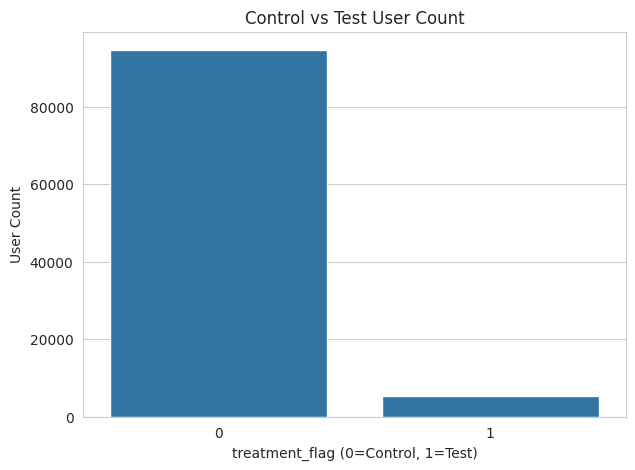

In [0]:
# 9. TREATMENT GROUP SPLIT
if "treatment_flag" in df.columns:
    grp = df["treatment_flag"].value_counts(dropna=False).sort_index().reset_index()
    grp.columns = ["treatment_flag", "count"]
    grp["pct"] = grp["count"] / grp["count"].sum() * 100
    print("\nTreatment Group Split")
    display(grp)

    plt.figure(figsize=(7,5))
    sns.barplot(data=grp, x="treatment_flag", y="count")
    plt.title("Control vs Test User Count")
    plt.xlabel("treatment_flag (0=Control, 1=Test)")
    plt.ylabel("User Count")
    plt.show()


Conversion Summary by Group


treatment_flag,count,conversion_rate,total_conversions,conversion_rate_pct
0,94600,0.023985200845665963,2269,2.3985200845665964
1,5400,0.034444444444444444,186,3.4444444444444446


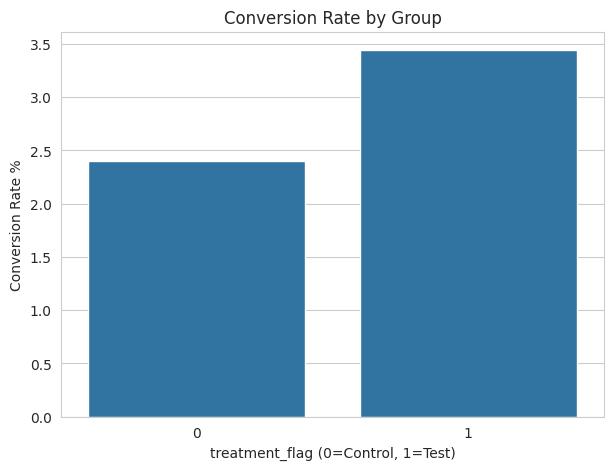


Lift Summary
Control Conversion Rate : 2.3985%
Test Conversion Rate    : 3.4444%
Absolute Lift           : 1.0459%
Relative Lift           : 43.61%


In [0]:
# 10. CONVERSION RATE BY GROUP
# -----------------------------
if set(["treatment_flag", "conversions"]).issubset(df.columns):
    conv_summary = (
        df.groupby("treatment_flag")["conversions"]
        .agg(["count", "mean", "sum"])
        .reset_index()
        .rename(columns={"mean": "conversion_rate", "sum": "total_conversions"})
    )
    conv_summary["conversion_rate_pct"] = conv_summary["conversion_rate"] * 100

    print("\nConversion Summary by Group")
    display(conv_summary)

    plt.figure(figsize=(7,5))
    sns.barplot(data=conv_summary, x="treatment_flag", y="conversion_rate_pct")
    plt.title("Conversion Rate by Group")
    plt.xlabel("treatment_flag (0=Control, 1=Test)")
    plt.ylabel("Conversion Rate %")
    plt.show()

    # Lift calculation
    if conv_summary.shape[0] == 2:
        control_rate = conv_summary.loc[conv_summary["treatment_flag"] == 0, "conversion_rate"].values[0]
        test_rate = conv_summary.loc[conv_summary["treatment_flag"] == 1, "conversion_rate"].values[0]
        abs_lift = test_rate - control_rate
        rel_lift = (test_rate / control_rate - 1) if control_rate > 0 else np.nan

        print("\nLift Summary")
        print(f"Control Conversion Rate : {control_rate:.4%}")
        print(f"Test Conversion Rate    : {test_rate:.4%}")
        print(f"Absolute Lift           : {abs_lift:.4%}")
        print(f"Relative Lift           : {rel_lift:.2%}")

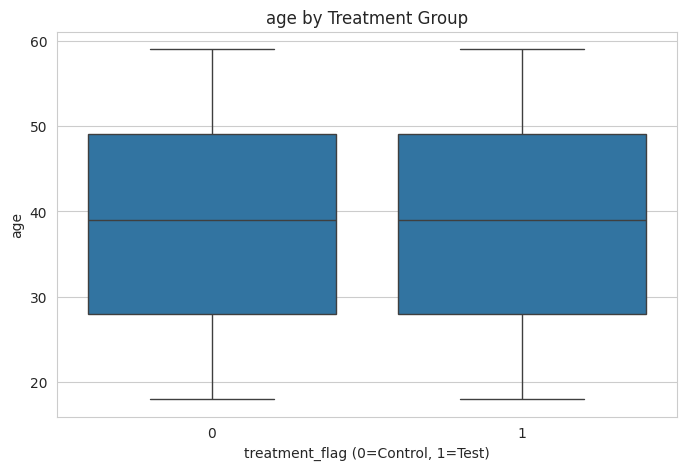

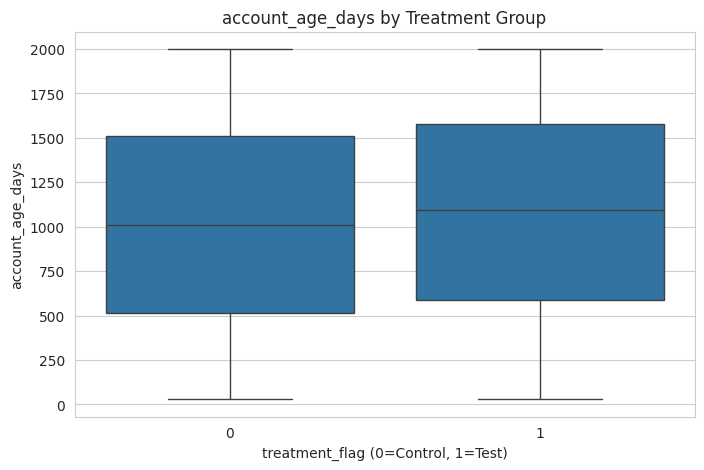

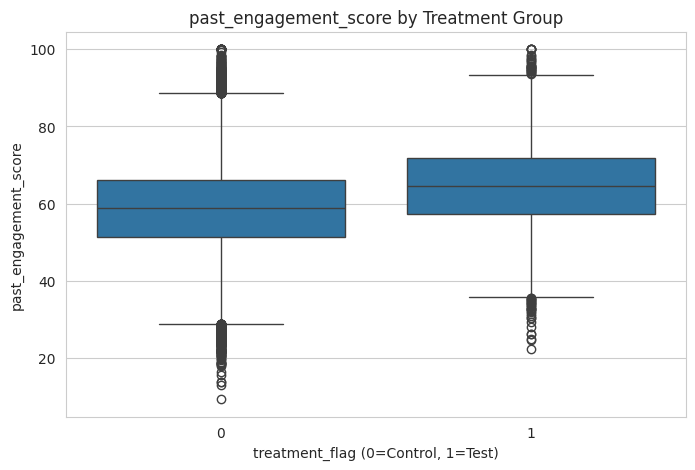

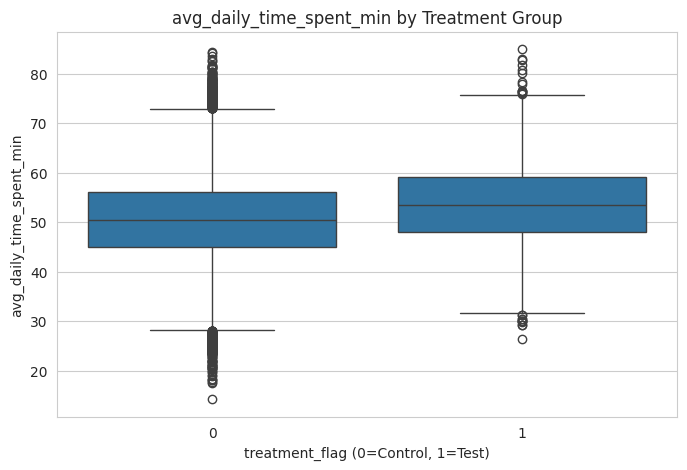

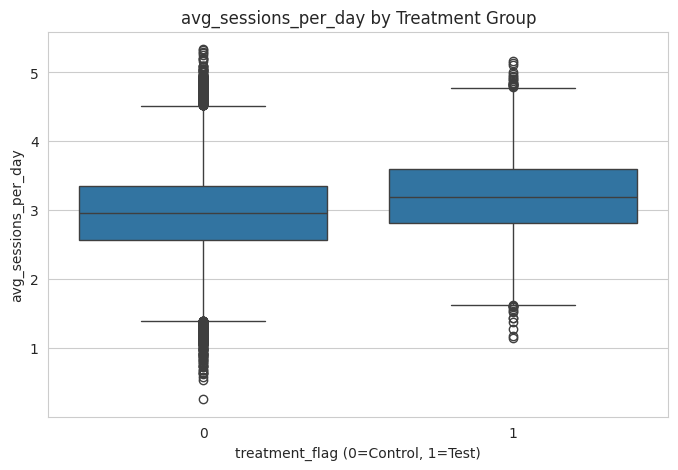

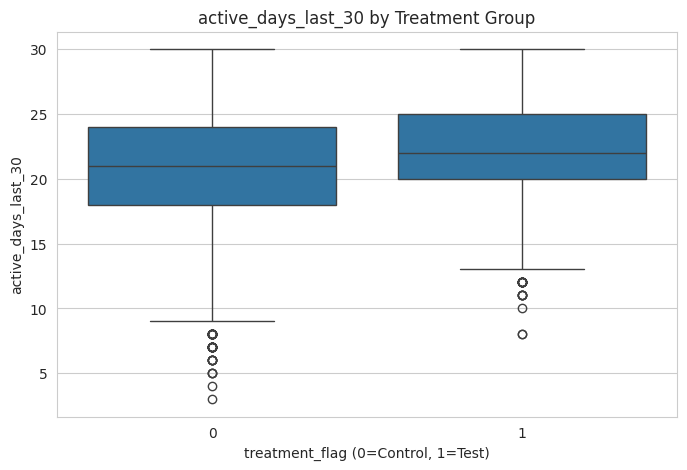

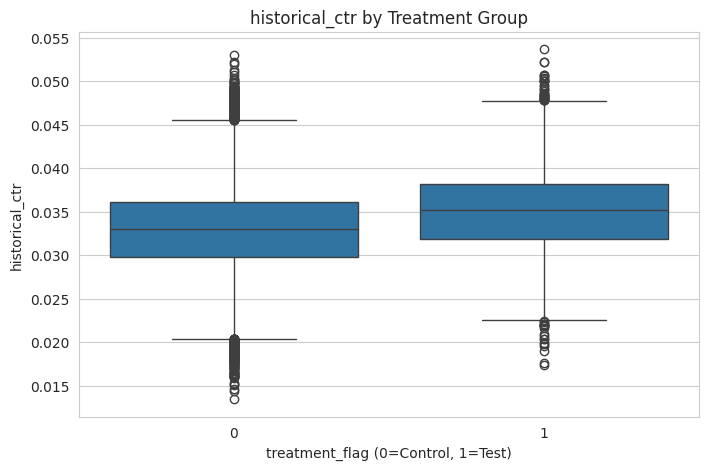

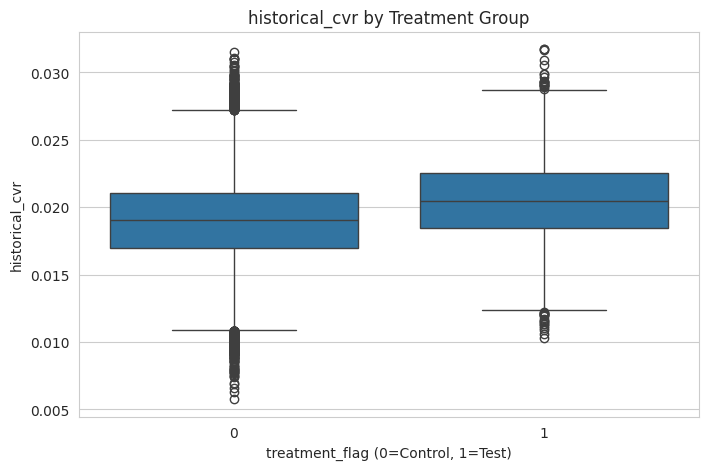

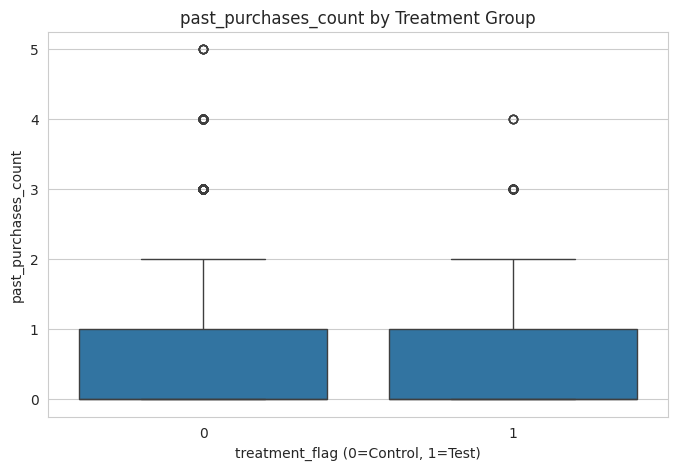

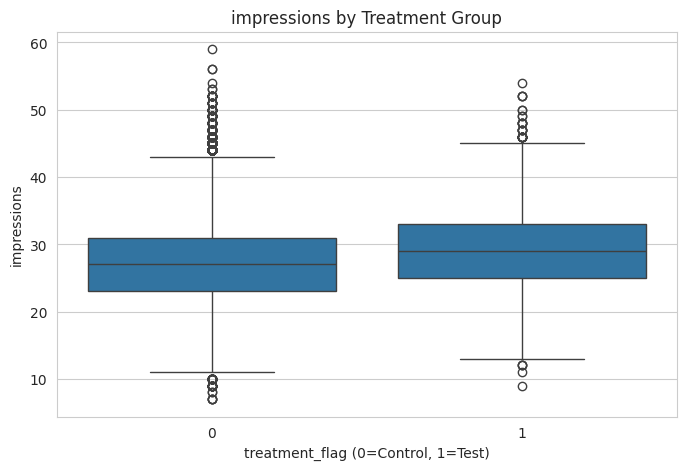

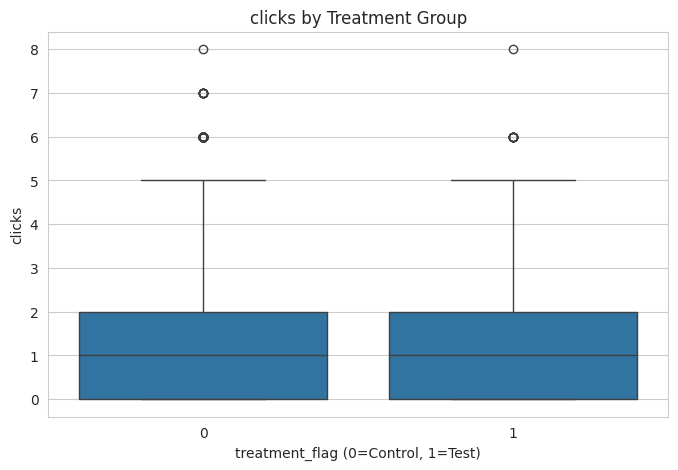

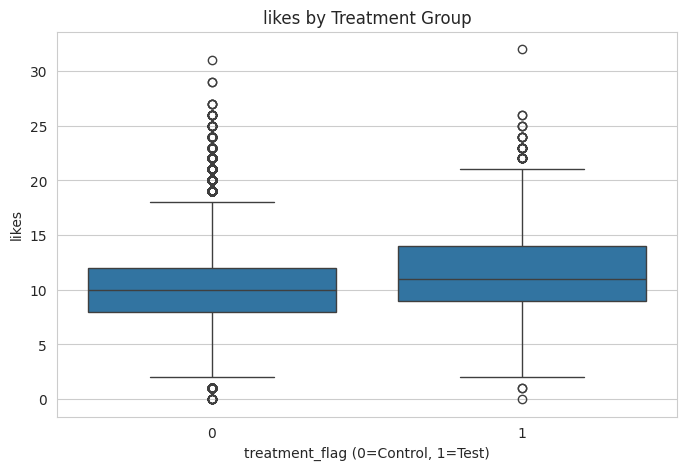

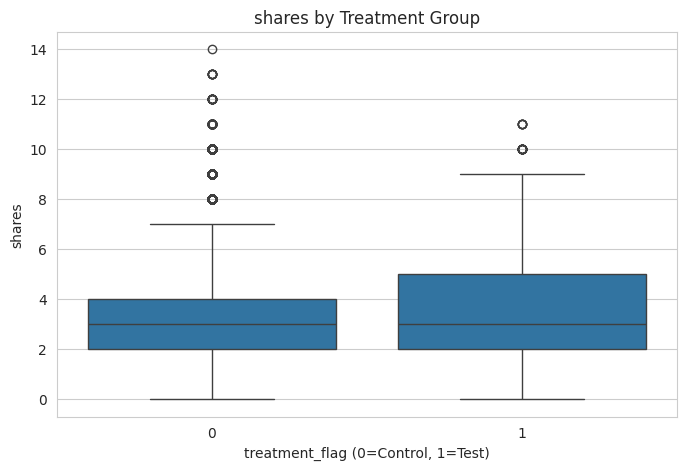

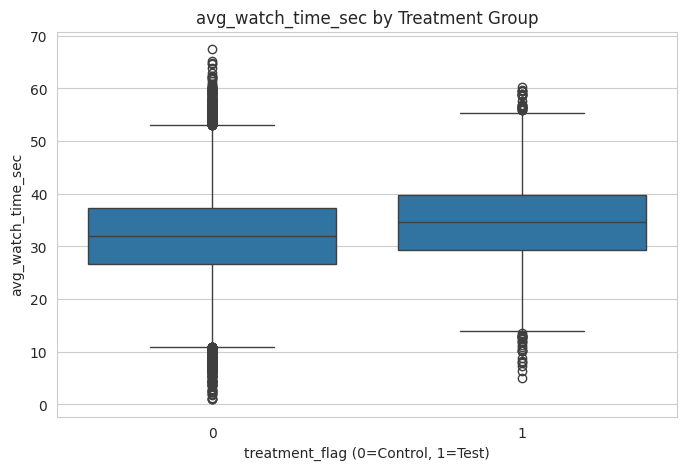

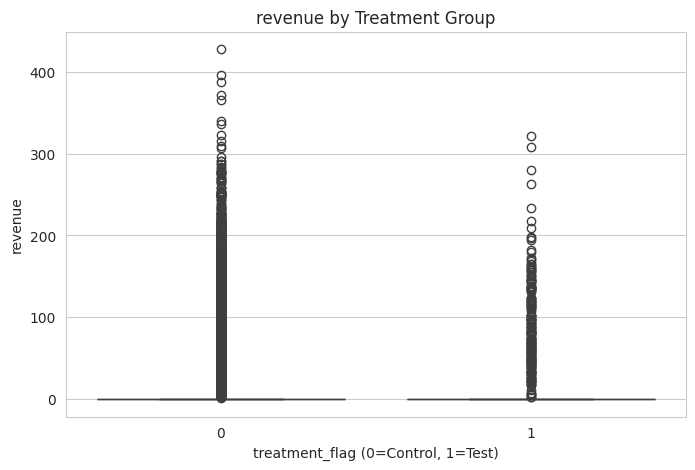

In [0]:
# 11. NUMERIC COMPARISON BY TREATMENT
if "treatment_flag" in df.columns:
    compare_cols = [
        c for c in [
            "age",
            "account_age_days",
            "past_engagement_score",
            "avg_daily_time_spent_min",
            "avg_sessions_per_day",
            "active_days_last_30",
            "historical_ctr",
            "historical_cvr",
            "past_purchases_count",
            "impressions",
            "clicks",
            "likes",
            "shares",
            "avg_watch_time_sec",
            "revenue"
        ] if c in df.columns
    ]

    for c in compare_cols:
        plt.figure(figsize=(8,5))
        sns.boxplot(data=df, x="treatment_flag", y=c)
        plt.title(f"{c} by Treatment Group")
        plt.xlabel("treatment_flag (0=Control, 1=Test)")
        plt.ylabel(c)
        plt.show()